# Business Case

## Customer Segmentation for Strategic Marketing and Sales

**K-means clustering**

**Business Context:**
The dataset comes from the UCI Machine Learning Repository – Online Retail dataset. It contains all transactions between 01/12/2010 and 09/12/2011 for a UK-based, registered non-store online retailer. The company mainly sells unique, all-occasion gifts, and a significant share of its customers are wholesalers.

**Business Goal:**
The objective is to segment customers based on their purchasing behavior to support targeted marketing campaigns, loyalty programs, and sales strategies.

By identifying distinct customer groups, the company can:

- Improve customer retention through personalized offers.

- Increase revenue by focusing on high-value segments.

- Design different strategies for wholesalers vs. retail consumers.

- Detect inactive customers and plan reactivation campaigns.




# Step 1: Problem definition
### Business Need
Maximize customer lifetime value by tailoring marketing, product and retention strategies to distinct customer segments identified through behavioral purchase data.

### Pain Point
The company serves both wholesale and retail customers, but there is no clear understanding of the behavioral differences between these groups or within them.
Marketing and retention campaigns are currently broad and generic — which likely leads to inefficient resource allocation, missed upsell opportunities and poor reactivation of inactive customers.

It is told there is variability in revenue across product lines, yet lack clarity on **which factors are most impactful** and **how to structure pricing or promotional strategies** to consistently maximize revenue.

This could be leading to inconsistent decision-making and missed opportunities for optimization.

### Objective
Use clustering techniques on aggregated customer-level metrics to:

- Identify distinct customer segments based on purchasing patterns.

- Profile each segment to understand its behavior and value to the business.

This segmentation will serve as a decision-support tool to guide targeted marketing, retention, and sales strategies.

### Expected Outcome

Identify key customer types
Understand which segments are made up of high-value frequent buyers, price-sensitive occasional shoppers, wholesalers, or inactive customers.

Reveal retention and reactivation opportunities
Detect customers at risk of churn (high recency, low frequency) and design tailored campaigns to bring them back.

#### Other outcomes given the context of the enterprise:

Support targeted marketing
Create offers, discounts, or product recommendations that align with each segment’s buying behavior.

Enable data-informed decision-making
Use behavioral profiles to prioritize investment in high-value segments and optimize acquisition costs.

Provide actionable insights to:

- Define loyalty program rules for different customer profiles.

- Personalize promotions based on purchase diversity and basket size.

- Distinguish between B2B wholesale and B2C retail customer behavior.

- Guide stock planning based on demand patterns of key segments.



# Step 2: Data Collection

The dataset was sourced from the UCI Machine Learning Repository and contains transactional-level records, including:

Column	Description
InvoiceNo	Unique transaction identifier (prefixed with 'C' for cancellations).
StockCode	Product (item) code.
Description	Product description.
Quantity	Number of units purchased.
InvoiceDate	Date and time of transaction.
UnitPrice	Price per unit (£).
CustomerID	Unique customer identifier.
Country	Country where the customer resides.

Data granularity:

Each row represents a single transaction line (one product per invoice).

The dataset will be aggregated at the customer level to compute behavior metrics such as:

- Recency (days since last purchase)

- Frequency (number of distinct purchases)

- Monetary (total value spent)

- Product Diversity (unique products purchased)

- Average Basket Size (average quantity per purchase)

These metrics will then serve as features for the clustering model.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Online_Retail.csv",encoding="UTF-8")

In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df['CustomerID'] =df['CustomerID'].astype('Int64') # Int64 supports missing values


In [6]:
df = df.convert_dtypes()
df.dtypes

InvoiceNo      string[python]
StockCode      string[python]
Description    string[python]
Quantity                Int64
InvoiceDate    string[python]
UnitPrice             Float64
CustomerID              Int64
Country        string[python]
dtype: object

In [7]:
df.head(4)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850,United Kingdom


## 2.1 Data Cleaning

### 2.1.1 Handling null values

I usually go for the strategy of: <br>
- understanding the features that have the nulls
- see their number and weight on the column
- if threshold of 20% per col is reached for example, I drop the rows; if not could reached, I try to see a fill with average, median or mode values; or other suited value chosen; -> evaluate on EDA impact afterwards;

This decisions are always aligned with the given context of business.

In [8]:
df.isnull().sum().sum()

np.int64(136534)

In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
(df.isnull().mean() * 100).round(2)

InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64

In [11]:
null_customers = df[df['CustomerID'].isnull()]
null_customers.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,<NA>,56,01/12/2010 11:52,0.0,<NA>,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,01/12/2010 14:32,2.51,<NA>,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,01/12/2010 14:32,2.51,<NA>,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,01/12/2010 14:32,0.85,<NA>,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,01/12/2010 14:32,1.66,<NA>,United Kingdom


In [12]:
df = df.dropna(subset=['CustomerID'])

In [13]:
(df.isnull().mean() * 100).round(2)

InvoiceNo      0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
UnitPrice      0.0
CustomerID     0.0
Country        0.0
dtype: float64

In [14]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,406829.0,406829.0,406829.0
mean,12.061303,3.460471,15287.69057
std,248.69337,69.315162,1713.600303
min,-80995.0,0.0,12346.0
25%,2.0,1.25,13953.0
50%,5.0,1.95,15152.0
75%,12.0,3.75,16791.0
max,80995.0,38970.0,18287.0


### 2.1.2 Checking for duplicates

In [15]:
df.duplicated().sum()

np.int64(5225)

In [16]:
df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

Now the dataset is cleaned and we can advanced further for EDA Step and afterwards to the transformations of variables we see fit for better model performance.

# Step: 3 EDA (exploratory data analysis)

After EDA is done, it's possible to decide which variables to include (the ones that can add value to explaining output) and be part of the dataset to feed data to the model afterwards!


In [18]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
df = df[df['Country'] == 'United Kingdom'] # to analyse only UK customers purchase behaviour; decision made after first EDA;

### 3.1 Numeric variables analysis

In [20]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()  # selecting only the cols with numeric data type
df[numeric_cols].describe().T.round(2) # stats about the cols, transposed view

,count,mean,std,min,25%,50%,75%,max
Quantity,356728.0,11.2,265.0,-80995.0,2.0,4.0,12.0,80995.0
UnitPrice,356728.0,3.27,71.16,0.0,1.25,1.95,3.75,38970.0
CustomerID,356728.0,15543.8,1594.29,12346.0,14191.0,15513.0,16931.0,18287.0


From this table I can see that quantity has negative values that could refer to returns/refunds for the online store.

The idea here will be to exclude these type of transactions, so we can focuses only on the purchase behaviour.


In the numeric variables, we observe:

- Quantity: ranges from large negative values to very high positives. Negative quantities typically indicate returns or adjustments. These can either be excluded (to focus on purchases) or analysed separately (to identify customers with high return behaviour).

- UnitPrice: most values are positive, but there are cases with price = 0, which might represent samples, replacements, or data entry errors. They should be excluded from revenue calculations to avoid distorting results.

- CustomerID: IDs are numeric codes identifying customers. Rows with missing IDs represent anonymous transactions are excluded from customer-level segmentation.


In [21]:
# negative check

neg_qty = df[df['Quantity'] < 0].sort_values('InvoiceDate',ascending=False)
neg_qty.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
429996,C573575,CRUK,CRUK Commission,-1,31/10/2011 14:09,606.0,14096,United Kingdom
429024,C573541,23462,ROCOCO WALL MIRROR WHITE,-1,31/10/2011 12:57,19.95,14738,United Kingdom
428880,C573502,21913,VINTAGE SEASIDE JIGSAW PUZZLES,-2,31/10/2011 12:02,3.75,14808,United Kingdom
428873,C573502,22064,PINK DOUGHNUT TRINKET POT,-2,31/10/2011 12:02,1.65,14808,United Kingdom
428874,C573502,23389,SPACEBOY MINI BACKPACK,-2,31/10/2011 12:02,4.15,14808,United Kingdom
428875,C573502,23390,DOLLY GIRL MINI BACKPACK,-1,31/10/2011 12:02,4.15,14808,United Kingdom
428876,C573502,84674,FLYING PIG WATERING CAN,-4,31/10/2011 12:02,2.95,14808,United Kingdom
428877,C573502,21888,BINGO SET,-2,31/10/2011 12:02,3.75,14808,United Kingdom
428878,C573502,22550,HOLIDAY FUN LUDO,-7,31/10/2011 12:02,3.75,14808,United Kingdom
428879,C573502,23229,VINTAGE DONKEY TAIL GAME,-2,31/10/2011 12:02,3.75,14808,United Kingdom


Visible that negative records have C before number of the original 'InvoiceNo'

In [22]:
# Variables for quick change
stock_code = '22557'
customer_id = 17548

# Filter dynamically
filtered_df = df[
    (df['StockCode'] == stock_code) &
    (df['CustomerID'] == customer_id)
]

# Optional: sort by date to see the timeline
filtered_df = filtered_df.sort_values('InvoiceDate')

filtered_df


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,01/12/2010 10:24,1.65,17548,United Kingdom


In [23]:
# Variables for quick change
InvoiceNo = '573502'	


# Filter dynamically
filtered_df = df[
    (df['InvoiceNo'] == InvoiceNo)
]

# Optional: sort by date to see the timeline
filtered_df = filtered_df.sort_values('InvoiceDate')

filtered_df


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


It seems that the original purchase is not present. So it follows that info. from the dataset.

In [24]:
neg_qty.groupby(['Country','Description'])['Quantity'].sum().sort_values().head(10)

Country         Description                        
United Kingdom  PAPER CRAFT , LITTLE BIRDIE            -80995
                MEDIUM CERAMIC TOP STORAGE JAR         -74467
                ROTATING SILVER ANGELS T-LIGHT HLDR     -9361
                Manual                                  -3456
                FAIRY CAKE FLANNEL ASSORTED COLOUR      -3150
                WHITE HANGING HEART T-LIGHT HOLDER      -2551
                GIN + TONIC DIET METAL SIGN             -2029
                HERB MARKER BASIL                       -1527
                FELTCRAFT DOLL MOLLY                    -1446
                TEA TIME PARTY BUNTING                  -1424
Name: Quantity, dtype: Int64

In [25]:
df = df[df['Quantity'] > 0] # to remove the negative qty purchases

Removing transactions with zero UnitPrice.

For the default meaning could represent samples or errors on data introduction.
Since this transactions won't generate revenue -> they will impact negatively future analysis on RFM;

Furthermore by targeting groups of clients based on purchase value, this transactions will be of no use.

In [26]:
df = df[df['UnitPrice'] > 0] 


In [27]:
#df = df[:20]

Plotting visuals can help to understand our distribution in each feature. Therefore ahistogram and also a box plot will help in this matter;

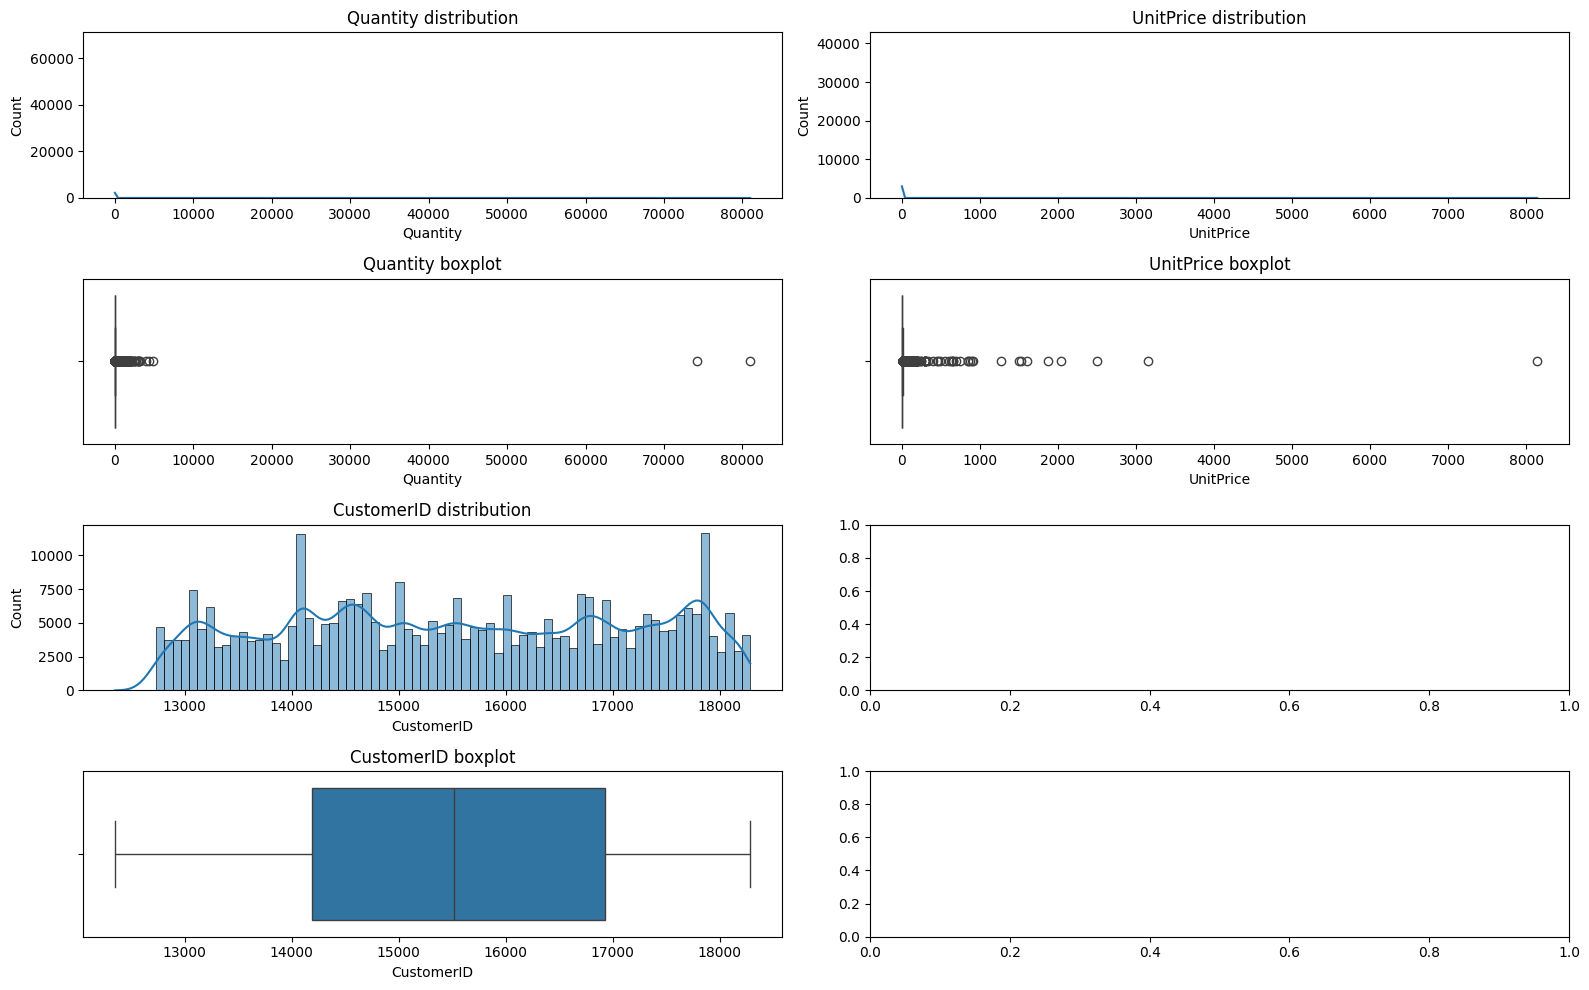

In [28]:
from math import ceil

cols_per_row = 2
num_vars = len(numeric_cols)
rows = ceil(num_vars / cols_per_row) * 2 

fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 8, rows * 2.5)) # creating the figure & axes matrix; figsize is about dimensions to give space for charts
axes = axes.flatten()  # to return a 1D array so we iterate over, axes = [0,1,2,3,4,5,6,7] 

for idx, col in enumerate(numeric_cols):
    # to calculate the coordinates
    row_offset = (idx // cols_per_row) * cols_per_row * 2 
    col_offset = idx % cols_per_row # use a sequence where since cols per row is 2, its a even number, so when iterating, position in 0 or 1 col pos

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[row_offset + col_offset])
    axes[row_offset + col_offset].set_title(f"{col} distribution")

    # Boxplot 
    sns.boxplot(x=df[col], ax=axes[row_offset + cols_per_row + col_offset], orient='h')
    axes[row_offset + cols_per_row + col_offset].set_title(f"{col} boxplot")

plt.tight_layout()
plt.show()

In [29]:
#See the highest outliers on UnitPrice:
df.sort_values('UnitPrice', ascending=False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
173382,551697,POST,POSTAGE,1,03/05/2011 13:46,8142.75,16029,United Kingdom
374542,569382,M,Manual,1,03/10/2011 16:44,3155.95,15502,United Kingdom
297438,562946,M,Manual,1,11/08/2011 09:38,2500.0,15581,United Kingdom
343000,566927,M,Manual,1,15/09/2011 15:20,2033.1,17846,United Kingdom
150615,549468,M,Manual,1,08/04/2011 14:27,1867.86,17940,United Kingdom
528082,580727,DOT,DOTCOM POSTAGE,1,05/12/2011 17:17,1599.26,14096,United Kingdom
508459,579196,DOT,DOTCOM POSTAGE,1,28/11/2011 15:54,1526.76,14096,United Kingdom
467436,576339,DOT,DOTCOM POSTAGE,1,14/11/2011 15:27,1500.36,14096,United Kingdom
494728,578270,DOT,DOTCOM POSTAGE,1,23/11/2011 13:39,1270.06,14096,United Kingdom
455261,575607,DOT,DOTCOM POSTAGE,1,10/11/2011 12:37,908.16,14096,United Kingdom


Since the values seem to be on a manual category we will try to take out based on IQR;

For the sake of exercise

In [30]:
#See the highest outliers on Quantity:

df.sort_values('Quantity', ascending=False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,09/12/2011 09:15,2.08,16446,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,18/01/2011 10:01,1.04,12346,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,27/10/2011 12:26,0.21,12901,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,27/05/2011 10:52,0.72,13135,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,22/02/2011 10:43,0.82,18087,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,19/07/2011 17:04,0.06,14609,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,11/01/2011 12:55,2.1,15749,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,18/04/2011 13:20,2.1,15749,United Kingdom
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,02/11/2011 11:24,0.32,16308,United Kingdom
291249,562439,84879,ASSORTED COLOUR BIRD ORNAMENT,2880,04/08/2011 18:06,1.45,12931,United Kingdom


In [31]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    return outliers, lower_limit, upper_limit

In [32]:
# Outliers Quantity
out_qty, low_qty, high_qty = detect_outliers_iqr(df, 'Quantity')
print(f"Quantity outliers: {len(out_qty)} ({len(out_qty)/len(df)*100:.2f}%)")
print(f"Lower limit: {low_qty:.2f} | Upper limit: {high_qty:.2f}")

Quantity outliers: 20218 (5.79%)
Lower limit: -13.00 | Upper limit: 27.00


In [33]:
# Outliers UnitPrice
out_price, low_price, high_price = detect_outliers_iqr(df, 'UnitPrice')
print(f"UnitPrice outliers: {len(out_price)} ({len(out_price)/len(df)*100:.2f}%)")
print(f"Lower limit: {low_price:.2f} | Upper limit: {high_price:.2f}")

UnitPrice outliers: 28904 (8.28%)
Lower limit: -2.50 | Upper limit: 7.50


In [34]:
df_model = df[
    (df['Quantity'] >= low_qty) & (df['Quantity'] <= high_qty) &
    (df['UnitPrice'] >= low_price) & (df['UnitPrice'] <= high_price)
].copy()

### 3.2 Categorical variables analysis

In [35]:
#categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()


df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True, errors='coerce')


df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)




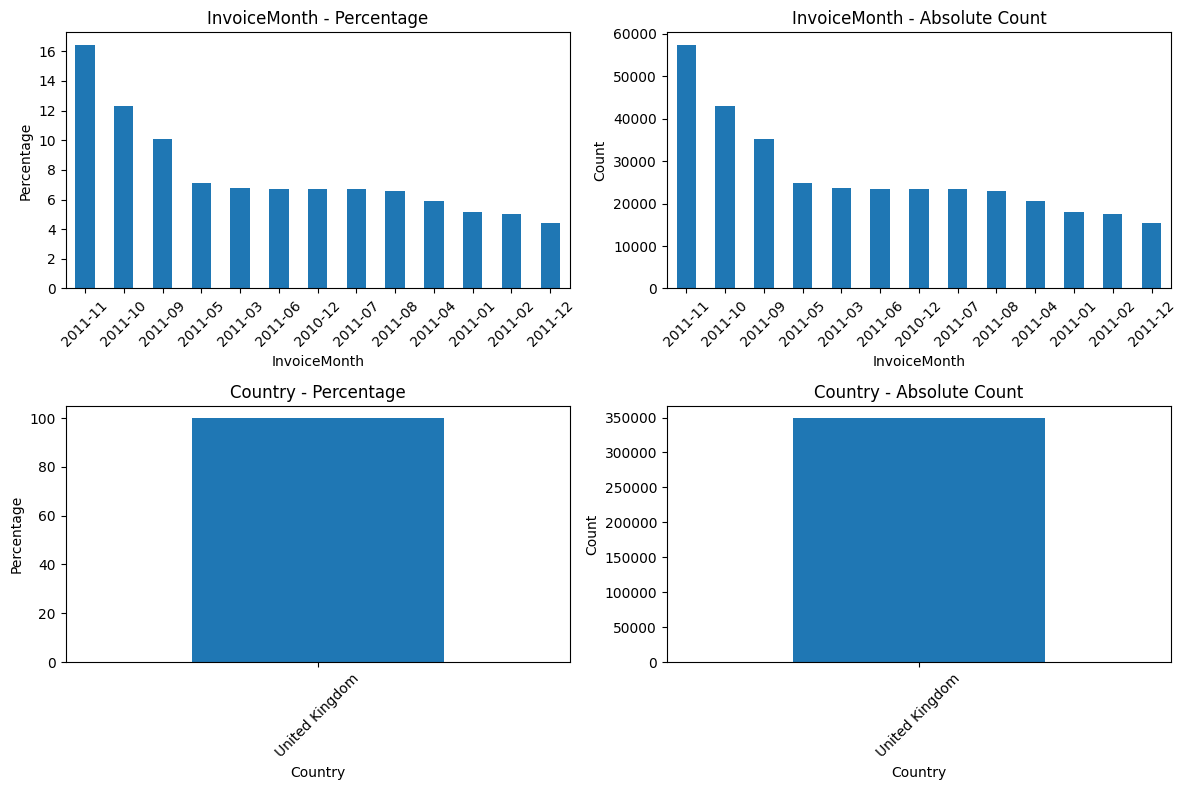

In [36]:
import matplotlib.pyplot as plt

categorical_cols = ['InvoiceMonth', 'Country']

n_vars = len(categorical_cols)
fig, axes = plt.subplots(n_vars, 2, figsize=(12, 4 * n_vars))  

if n_vars == 1:
    axes = [axes]

for i, col in enumerate(categorical_cols):
    # Absolute counts
    df[col].value_counts().plot(kind='bar', ax=axes[i][1])
    axes[i][1].set_title(f"{col} - Absolute Count")
    axes[i][1].tick_params(axis='x', rotation=45)
    axes[i][1].set_ylabel("Count")

    # Percentages
    (df[col].value_counts(normalize=True) * 100).plot(kind='bar', ax=axes[i][0])
    axes[i][0].set_title(f"{col} - Percentage")
    axes[i][0].tick_params(axis='x', rotation=45)
    axes[i][0].set_ylabel("Percentage")

plt.tight_layout()
plt.show()

Distribution on categories by variables on % and absolute values; could help understand better the business step up for better interpretation of the model to be created.

## 3.3 Bivariate analysis

### 3.3.1 Correlation

Creation of a correlation Matrix can help us identify which variables are correlated between each other and avoid multicollinearity (important for model outcome); 
- plus their relationship of influence on the outcome variable - target revenue;
- also understand if business knowledge previoulsy gather is aligned with data and vice-versa;

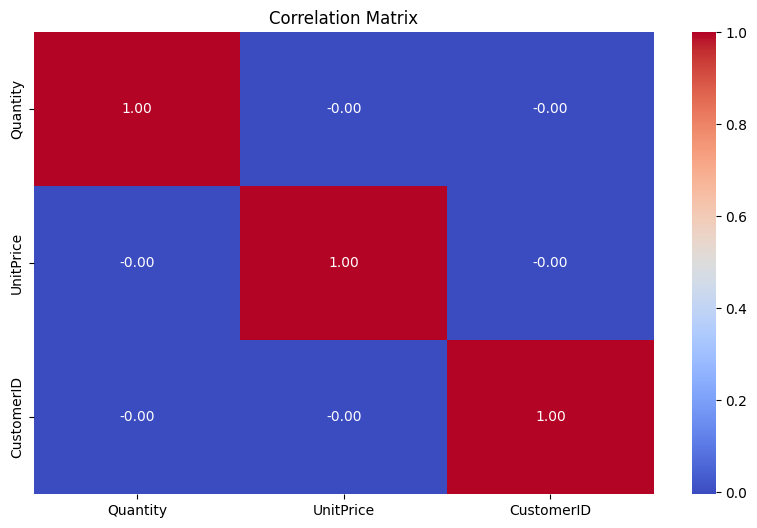

In [37]:
plt.figure(figsize=(10, 6))
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

After analysing at row-level transactions, the following shows summaries on customer level:

In [38]:
ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [39]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [40]:
# RFM metrics
rfm = df.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x: (ref_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary = ('TotalPrice', 'sum')  
).reset_index().sort_values('Monetary',ascending=False)
rfm

,CustomerID,Recency,Frequency,Monetary
3783,18102,1,60,259657.3
3314,17450,8,46,194390.79
2598,16446,1,2,168472.5
3356,17511,3,31,91062.38
2294,16029,39,63,80850.84
...,...,...,...,...
2913,16878,84,1,13.3
3680,17956,249,1,12.75
2604,16454,45,2,6.9
1398,14792,64,1,6.2


In [41]:
# Product diversity

product_div = df.groupby('CustomerID')['StockCode'].nunique().reset_index()
product_div.columns = ['CustomerID', 'ProductDiversity']

In [42]:
avg_basket = df.groupby('CustomerID').apply(
    lambda x: x['Quantity'].sum() / x['InvoiceNo'].nunique()
).reset_index(name='AvgBasketSize')
avg_basket

C:\Users\rpinto\AppData\Local\Temp\ipykernel_34560\3927928540.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_basket = df.groupby('CustomerID').apply(


,CustomerID,AvgBasketSize
0,12346,74215.000000
1,12747,115.909091
2,12748,120.990431
3,12749,294.200000
4,12820,180.500000
...,...,...
3915,18280,45.000000
3916,18281,54.000000
3917,18282,51.500000
3918,18283,84.812500


In [43]:
cust_df = rfm.merge(product_div, on='CustomerID') \
             .merge(avg_basket, on='CustomerID')

cust_df.head()

,CustomerID,Recency,Frequency,Monetary,ProductDiversity,AvgBasketSize
0,18102,1,60,259657.3,150,1068.733333
1,17450,8,46,194390.79,124,1521.152174
2,16446,1,2,168472.5,3,40498.500000
3,17511,3,31,91062.38,453,2082.225806
4,16029,39,63,80850.84,44,636.634921


In [44]:
cust_metrics = ['Recency','Frequency','Monetary','ProductDiversity','AvgBasketSize']
cust_df[cust_metrics].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Recency,3920.0,92.208418,99.533854,1.0,18.0,51.0,143.0,374.0
Frequency,3920.0,4.246429,7.199202,1.0,1.0,2.0,5.0,209.0
Monetary,3920.0,1858.424654,7478.631256,3.75,298.185,644.975,1571.285,259657.3
ProductDiversity,3920.0,60.726531,81.670816,1.0,15.0,35.0,77.0,1768.0
AvgBasketSize,3920.0,242.105368,1373.096462,1.0,90.0,154.928571,259.233333,74215.0



Exploring insights:

| Column               | Meaning                      | Insight it gives                                            |
| -------------------- | ---------------------------- | ----------------------------------------------------------- |
| **CustomerID**       | Unique customer code.        | Used as an identifier, not for clustering directly.         |
| **Recency**          | Days since last purchase.    | Lower = more recent customer; higher = inactive for longer. |
| **Frequency**        | Number of distinct invoices. | Higher = loyal/returning customer.                          |
| **Monetary**         | Total spending (€).          | Higher = more valuable customer.                            |
| **ProductDiversity** | Unique products purchased.   | Higher = customer buys across more product categories.      |
| **AvgBasketSize**    | Average quantity per order.  | Higher = customer tends to make bulk purchases.             |


In [45]:
# PLOTS: HIST + BOXPLOT (with percentil on input

def plot_metrics_distributions(df_metrics, cols, top_percentile=99.0, use_log=False):
    """
    df_metrics: DataFrame with metrics on customer
    cols: list to be considered
    top_percentile: to adjuste visualization
    use_log: if true, shows log 10 charts for variables, useful for skewed distributions
    """
    n = len(cols)
    rows = n
    extra = 1 if use_log else 0
    fig, axes = plt.subplots(rows, 2 + extra, figsize=(6*(2+extra), 3.5*rows))
    if n == 1:
        axes = np.atleast_2d(axes)

    for i, col in enumerate(cols):
        series = df_metrics[col].dropna().astype(float)

        # Limits on percentile
        x_max = np.percentile(series, top_percentile)

        # Histogram
        axes[i,0].hist(series[series <= x_max], bins=40, edgecolor='black')
        axes[i,0].set_title(f"{col} — histogram (≤ P{top_percentile:.0f})")
        axes[i,0].set_xlabel(col); axes[i,0].set_ylabel("count")

        # Boxplot
        axes[i,1].boxplot(series[series <= x_max], vert=False, whis=1.5)
        axes[i,1].set_title(f"{col} — boxplot (≤ P{top_percentile:.0f})")
        axes[i,1].set_xlabel(col)

        # Histogram log10
        if use_log:
            s_pos = series[series > 0]   # log só para >0
            if len(s_pos) > 0:
                axes[i,2].hist(np.log10(s_pos[s_pos <= x_max]), bins=40, edgecolor='black')
                axes[i,2].set_title(f"{col} — log10 histogram (≤ P{top_percentile:.0f})")
                axes[i,2].set_xlabel(f"log10({col})"); axes[i,2].set_ylabel("count")
            else:
                axes[i,2].text(0.5, 0.5, "no positive values", ha='center', va='center')
                axes[i,2].set_axis_off()

    plt.tight_layout()
    plt.show()


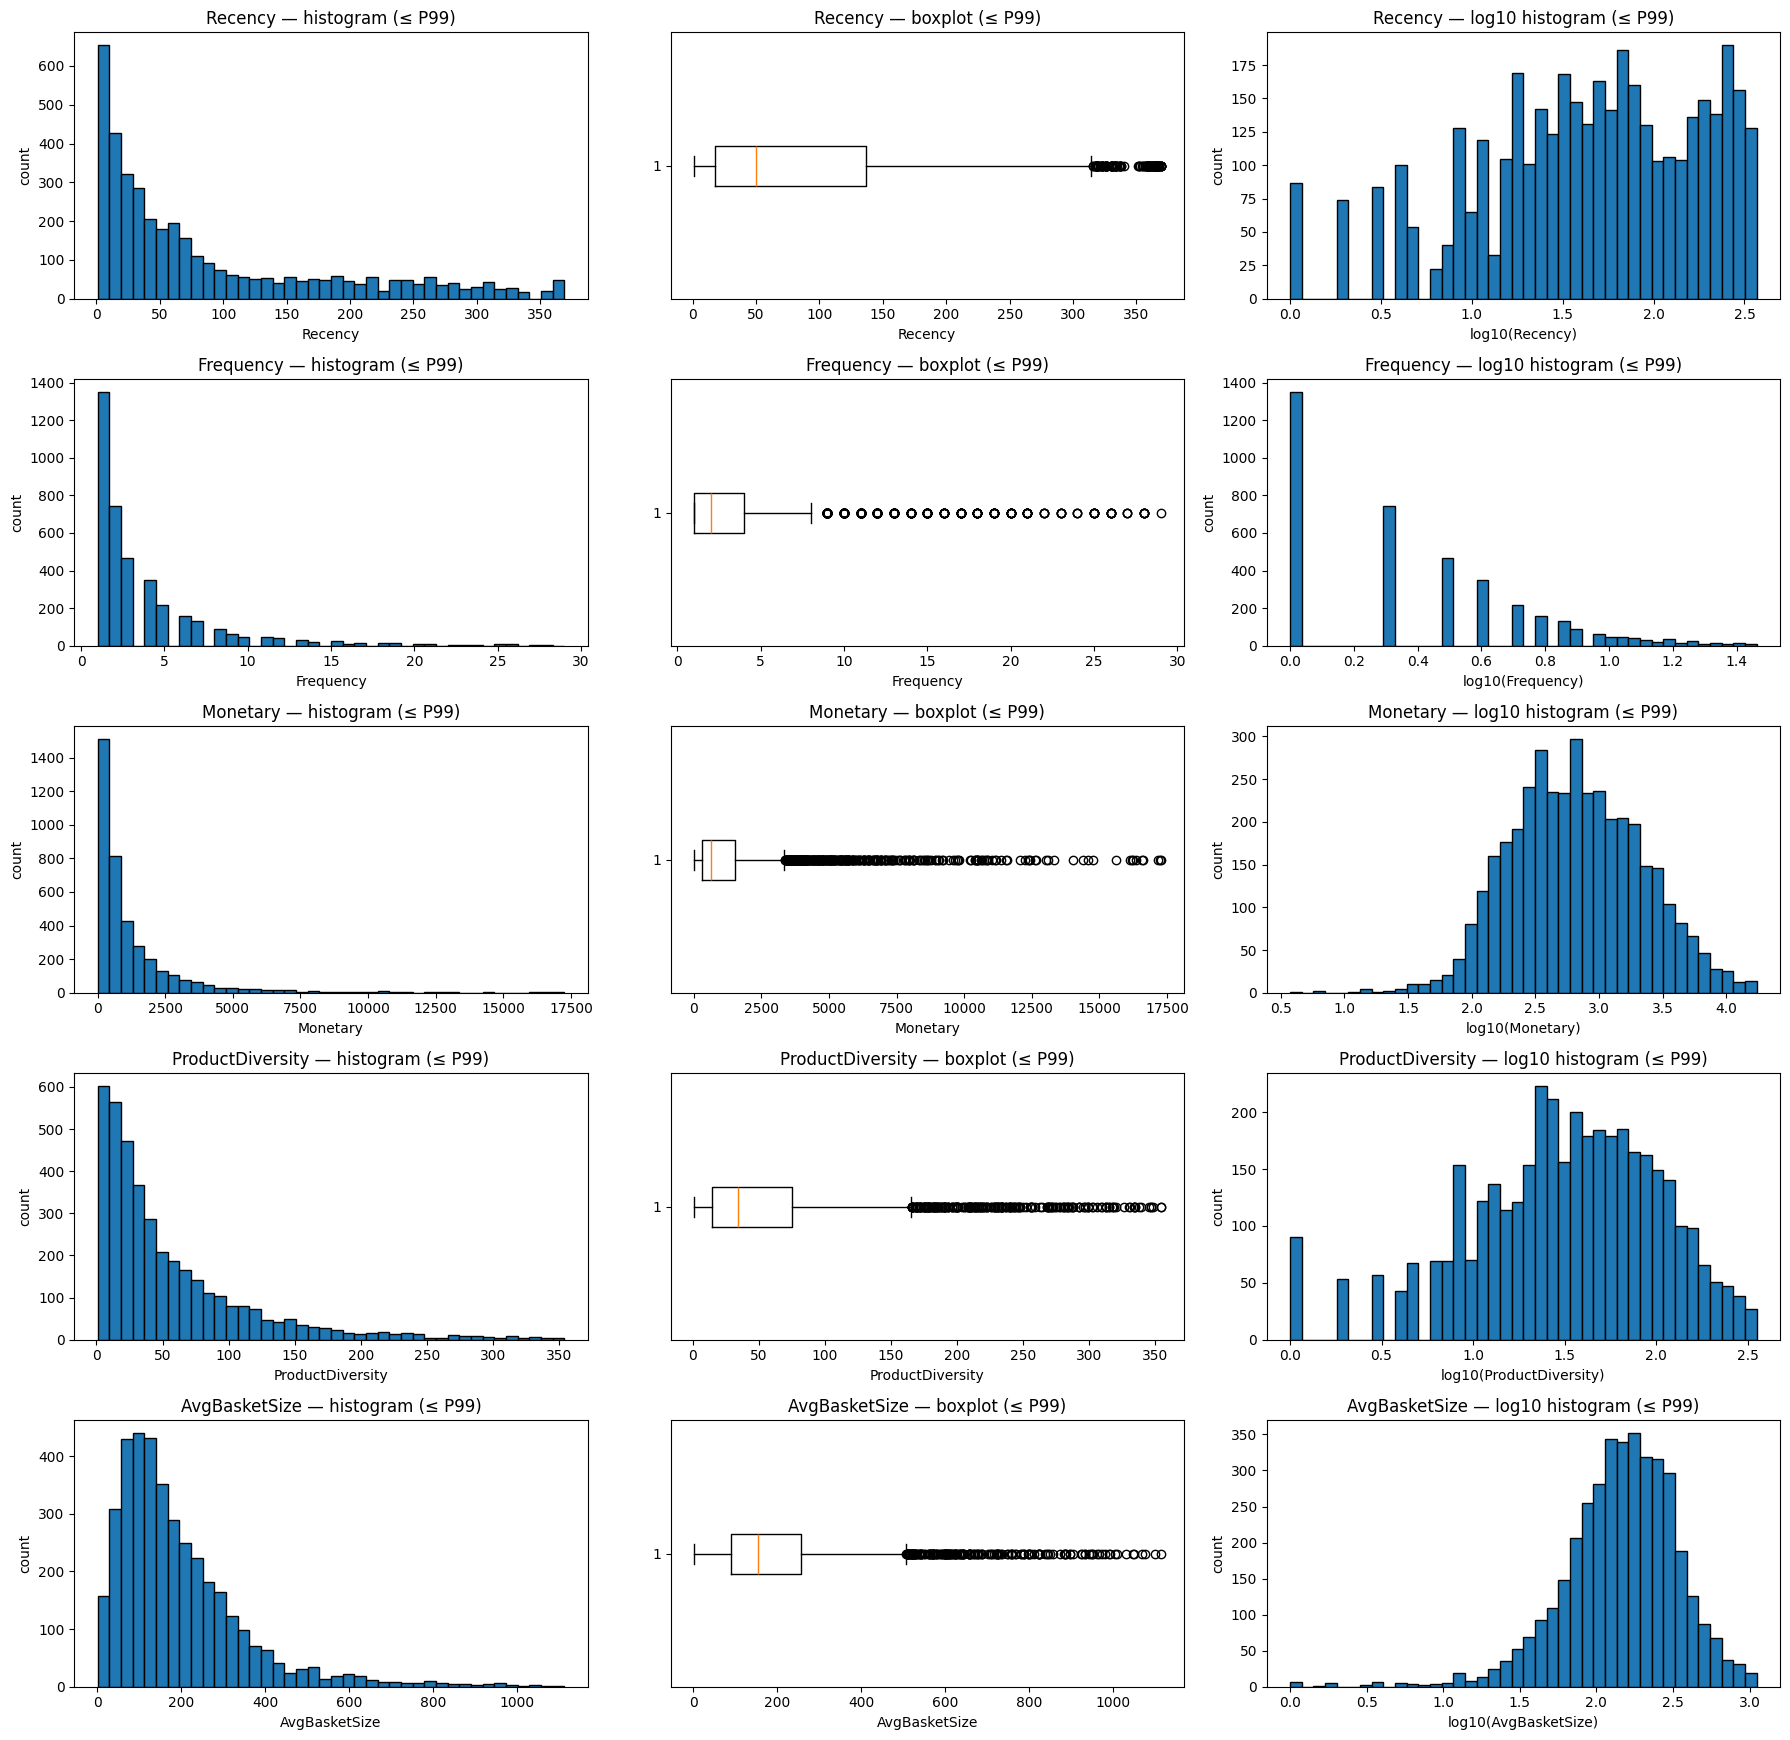

In [46]:
plot_metrics_distributions(cust_df, cust_metrics, top_percentile=99, use_log=True)




## Interpretation of the Metrics

### **1 Recency** — *Days since last purchase*

* **Histogram (≤ P99)**: shows that most customers purchased very recently (peak in the first \~50 days), but some haven’t bought in a long time.
* **Boxplot**: the median is low (\~50 days), but there are many high-recency outliers (inactive customers).
* **Log10**: used because the original scale is highly skewed — in log scale, the distribution becomes more “spread out” and visible.

  * **log10 range interpretation**:

    * **0–1** → **1–10 days**
    * **1–2** → **10–100 days**
    * **2–2.6** → **100–\~400 days**
* **Insight**: low recency customers are “hot” for campaigns; high recency ones may be inactive or lost for future sale.



### **2 Frequency** — *Number of distinct purchases (invoices)*

* **Histogram**: most customers have 1 to 3 purchases, and few buy many times.
* **Boxplot**: many outliers on the right side (super frequent customers).
* **Log10**: highlights the difference between low- and high-frequency customers, since in the original scale almost everyone is concentrated to the left.

  * **log10 range interpretation**:

    * **0–1** → **1–10 purchases**
    * **1–2** → **10–100 purchases**
    * **>2** → **>100 purchases**
* **Insight**: high-frequency customers are loyal — potential brand ambassadors; low-frequency ones may need reactivation.



### **3 Monetary** — *Total spend (€)*

* **Histogram**: highly left-skewed, with few customers spending very high amounts.
* **Boxplot**: strong asymmetry; outliers are very valuable customers -> possibly companies/wholesalers
* **Log10**: helps to see the distribution without extreme values “crushing” the rest.

  * **log10 range interpretation**:

    * **2.0–3.0** → **€100–€1,000**
    * **3.0–3.5** → **€1,000–\~€3,162**
    * **3.5–4.0** → **\~€3,162–€10,000**
    * **>4** → **>€10,000**
* **Insight**: essential to distinguish big from small customers; can be used for segmentation.



### **4 ProductDiversity** — *Number of unique products purchased*

* **Histogram**: most customers purchased up to \~50 different products, but some bought hundreds.
* **Boxplot**: outliers are customers who explore much of the catalogue.
* **Log10**: smooths the distribution and shows that most are concentrated at low ranges.

  * **log10 range interpretation**:

    * **1** → **10 products**
    * **2** → **100 products**
    * **3** → **1,000 products**
* **Insight**: high diversity suggests cross-category buying or wholesale; low diversity may indicate targeted, specific purchases.



### **5 AvgBasketSize** — *Average units per purchase*

* **Histogram**: very concentrated in the first hundreds, but some customers average thousands of units per transaction.
* **Boxplot**: strong outliers (likely wholesale stock purchases).
* **Log10**: makes the difference between small and medium/large baskets visible.

  * **log10 range interpretation**:

    * **1** → **10 units**
    * **2** → **100 units**
    * **3** → **1,000 units**
* **Insight**: very high average baskets probably indicate B2B customers; small baskets are more likely individual consumers.



## About **log10**

* The **logarithmic scale** is used to handle highly skewed distributions.
* In this dataset, several metrics have extreme values much higher than the average → in the normal histogram, the bulk of the data is “crushed” to the left.
* **log10** compresses high values and expands low values, making patterns much easier to see.



## About  P99 

* This means we only **plotted values up to the 99th percentile** (P99) to avoid a few outliers distorting the visualization.
* This is useful for **visualization purposes** but **does not remove** the outliers from the original dataset.






# Step 4: Creating the Model

This section is about storing the data in variables of use to be later called on the functions available in Scikit-learn library for the linear multiple regression model creation.

- It's important to validat any high correlation between features, to make decisions on reduction of dimensionalty and removing the right ones if needed.

### 4.1 Model Creation

In [47]:
# Feature selection
## Choosing variables that will be taken in account for clustering

features = ['Recency', 'Frequency', 'Monetary', 'ProductDiversity', 'AvgBasketSize']

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cust_df[features])


### Choosing k (number of clusters)

The number of clusters will be decided on these two tools:

- Elbow Method: plot inertia (within-cluster sum of squares) for different k values and look for the "elbow".

- Silhouette Score: measures cluster separation quality (closer to 1 = better separation).



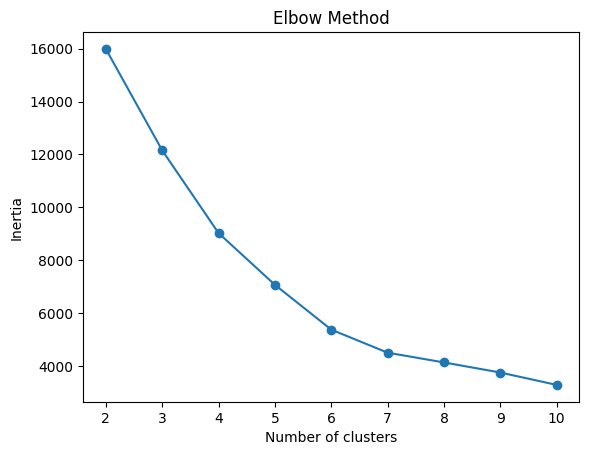

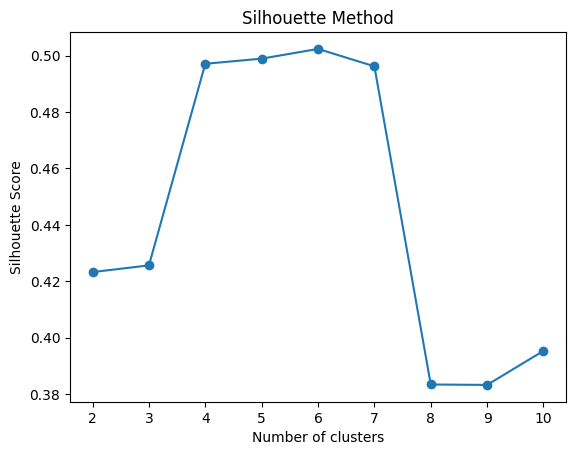

In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Plot Silhouette
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show()


As seen above the "elbow point" happens on 6 to 7, where the gain in inertia reduction is lower than the last addition form 5 to 6. Afterwards, the curve starts to flatten.

Therefore, the K that would be best to use would be 6, and it's coherent with the Silhoutte Method that should the best score for that Model above 0.5.

In [50]:
# Train final K-Means model
## Pick the k from the evaluation above , k= 6
## Fit the model and attach cluster labels to the dataframe

final_k = 6
kmeans = KMeans(n_clusters=final_k,random_state=42)

cust_df['Cluster'] = kmeans.fit_predict(X_scaled)


In [51]:
# Profiling clusters
## For each cluster, calculate mean/median of the features to see their profile

cluster_profile = cust_df.groupby('Cluster')[features].mean()
cluster_profile.round(2)


,Recency,Frequency,Monetary,ProductDiversity,AvgBasketSize
Cluster,,,,,
0,45.96,3.27,1088.47,48.33,215.00
1,247.35,1.58,522.35,24.00,169.15
2,163.50,1.50,122828.05,2.00,57356.75
3,17.05,13.95,6574.38,201.23,283.36
4,4.50,53.00,227024.04,137.00,1294.94
5,6.36,82.27,51807.17,733.91,681.06


In [52]:
# sizes & percentages of clusters
counts = cust_df.groupby('Cluster').size().rename('Count')
counts = counts.sort_values(ascending=False)  # biggest first
total  = counts.sum()
perc   = (counts / total * 100).round(2).rename('Percent')

cluster_size = pd.concat([counts, perc], axis=1)
cluster_size


,Count,Percent
Cluster,,
0,2522,64.34
1,962,24.54
3,421,10.74
5,11,0.28
2,2,0.05
4,2,0.05


In [53]:
# summary on merge

summary = cluster_size.join(cluster_profile)      
summary = summary.sort_values('Percent', ascending=False).round(2)
summary


,Count,Percent,Recency,Frequency,Monetary,ProductDiversity,AvgBasketSize
Cluster,,,,,,,
0,2522,64.34,45.96,3.27,1088.47,48.33,215.00
1,962,24.54,247.35,1.58,522.35,24.00,169.15
3,421,10.74,17.05,13.95,6574.38,201.23,283.36
5,11,0.28,6.36,82.27,51807.17,733.91,681.06
2,2,0.05,163.50,1.50,122828.05,2.00,57356.75
4,2,0.05,4.50,53.00,227024.04,137.00,1294.94


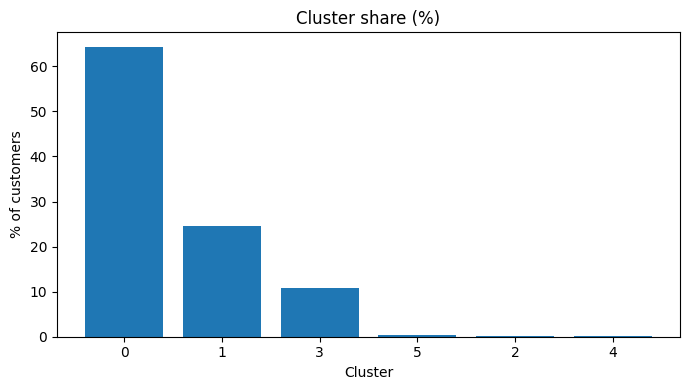

In [54]:
ax = cluster_size.reset_index().rename(columns={'index':'Cluster'})
ax = ax.sort_values('Percent', ascending=False)

plt.figure(figsize=(7,4))
plt.bar(ax['Cluster'].astype(str), ax['Percent'])
plt.title('Cluster share (%)')
plt.xlabel('Cluster')
plt.ylabel('% of customers')
plt.tight_layout()
plt.show()


In [55]:
# Visualizing in 2D
## Since there is a 5D data, reducing to 2D with PCA for plotting.

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

cust_df['PCA1'] = pca_result[:,0]
cust_df['PCA2'] = pca_result[:,1]


In [56]:
loadings = pd.DataFrame(
    pca.components_,
    columns=features,
    index=['PCA1', 'PCA2']
)
loadings


,Recency,Frequency,Monetary,ProductDiversity,AvgBasketSize
PCA1,-0.335644,0.589764,0.476093,0.538214,0.152260
PCA2,0.331315,-0.135251,0.447471,-0.260806,0.776973


The loadings say how much each **original feature**  contributes to each **principal component**:

- PCA1 (43.1% of variance)

    - Strong positive contributions: Frequency (0.59), ProductDiversity (0.54), Monetary (0.48)

    - Negative contribution: Recency (-0.33) — meaning customers with high PCA1 scores tend to have **high frequency, high diversity, high spend, and low recency (recent buyers)**.

    - This axis coul be a “Customer Value & Engagement” dimension.

- PCA2 (24.1% of variance)

    - Strong positive contributions: AvgBasketSize (0.78), Monetary (0.45)

    - Small negative contribution: Frequency (-0.13), ProductDiversity (-0.26)

    - This axis could be a “Basket Size / Purchase Style” dimension, separating customers who buy in large quantities (often B2B or wholesalers) from those with smaller baskets.

In [57]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.43132887, 0.24108464])

In [58]:
# mapping clusters
label_map = {
    0: "C1 – Low-Spend Occasional",
    1: "C2 – 'Inactive' Low-Value",
    3: "C4 – High-Freq Mid-Value",
    5: "C6 – High-Freq High-Value",
    2: "C3 – Infrequent Large-Order",
    4: "C5 – Rare Bulk Buyers"
}

cust_df['Cluster_Label'] = cust_df['Cluster'].map(label_map)

order = [
    "C1 – Low-Spend Occasional", 
    "C2 – 'Inactive' Low-Value", 
    "C3 – Infrequent Large-Order", 
    "C4 – High-Freq Mid-Value", 
    "C5 – Rare Bulk Buyers", 
    "C6 – High-Freq High-Value"
]

color_palette = sns.color_palette("colorblind", 6)


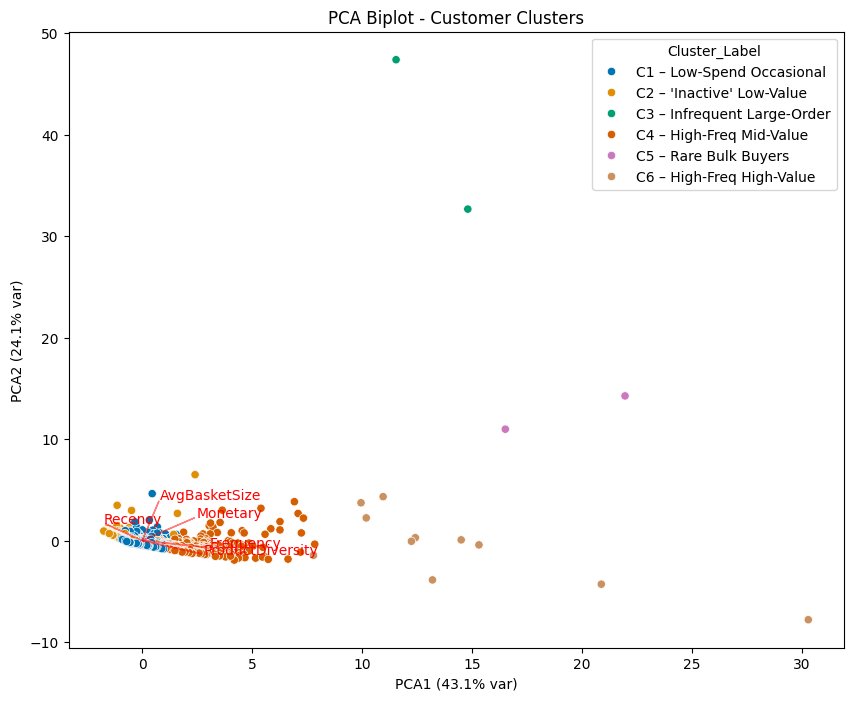

In [59]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=cust_df['Cluster_Label'],hue_order=order, palette=color_palette) # hue=cust_df['Cluster']
for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings.iloc[0, i]*5, loadings.iloc[1, i]*5, 
              color='r', alpha=0.5)
    plt.text(loadings.iloc[0, i]*5.2, loadings.iloc[1, i]*5.2, feature, color='r')
plt.xlabel(f"PCA1 ({explained_variance[0]*100:.1f}% var)")
plt.ylabel(f"PCA2 ({explained_variance[1]*100:.1f}% var)")
plt.title("PCA Biplot - Customer Clusters")
plt.show()


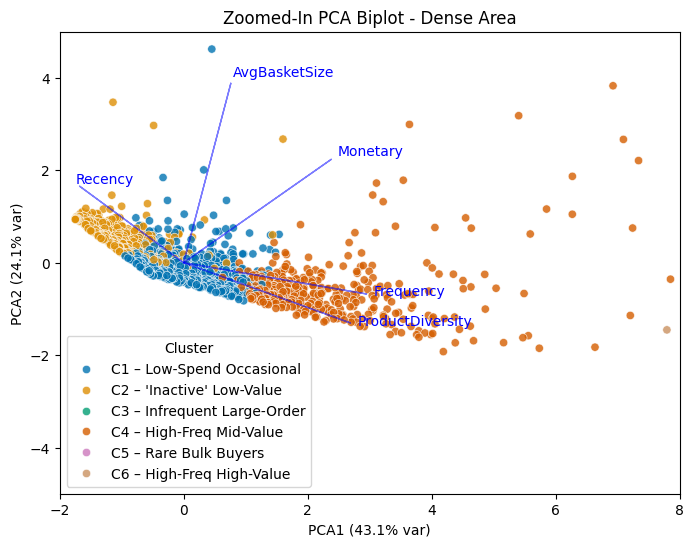

In [60]:
plt.figure(figsize=(8,6))

# Scatter with zoom
sns.scatterplot(
    x='PCA1', y='PCA2', 
    hue='Cluster_Label', 
    hue_order=order, 
    data=cust_df, 
    palette=color_palette, 
    alpha=0.8
)

# Arrows and labels for features
for i, feature in enumerate(features):
    plt.arrow(0, 0, 
              loadings.iloc[0, i]*5,  # scale factor for visibility
              loadings.iloc[1, i]*5, 
              color='b', alpha=0.5)
    plt.text(loadings.iloc[0, i]*5.2, 
             loadings.iloc[1, i]*5.2, 
             feature, color='b')

# Zoom limits
plt.xlim(-2, 8)
plt.ylim(-5, 5)

plt.xlabel(f"PCA1 ({explained_variance[0]*100:.1f}% var)")
plt.ylabel(f"PCA2 ({explained_variance[1]*100:.1f}% var)")
plt.title("Zoomed-In PCA Biplot - Dense Area")
plt.legend(title='Cluster')
plt.show()


The PCA1 (43.1%) + PCA2 (24.1%) ≈ 67.2% of the total variation that is shown in the 2D plot. The plot preserves most but not all information.

Clusters can be describred as:

- Bottom left (low PCA1, low PCA2) → low engagement, low spend, small baskets (occasional, low-value customers).

- Far right (high PCA1) → frequent, high-spending, diverse-product customers (loyal and engaged).

- Top (high PCA2) → large average basket size (possibly bulk buyers)

# Step 5: Business recommendations

### **Cluster 1 (64.34% of customers) – Low Engagement, Small Baskets – Low-Spend Occasional**
- **Profile:** Moderate recency (~46 days), low frequency (3.27), low spend (€1,088), moderate product diversity (~48 SKUs), small baskets (€215).
- **PCA Position:** Low PCA1, low PCA2 → low engagement & low value.
- **Recommendation:** 
  - Deploy **re-engagement campaigns** (email, seasonal promotions).
  - Offer **small basket incentives** like free shipping over a certain spend.
  - Focus on **cross-selling** to increase product diversity.



### **Cluster 2 (24.54% of customers) – "Inactive" Low-Value Buyers – 'Inactive' Low-Value**
- **Profile:** Very high recency (~247 days since last purchase), very low frequency (1.58), low spend (€522), low diversity (~24 SKUs), smallest baskets (€169).
- **PCA Position:** Low PCA1, low PCA2 → least engaged segment.
- **Recommendation:** 
  - Consider **win-back campaigns** (personalized offers).
  - Evaluate if long-term retention investment is worth the cost.
  - Focus marketing only if historical data shows potential ROI.

Side notes:
- They are customers who used to buy but are now inactive or almost inactive and when they did buy, they spent little and bought few products.
- They are at high risk of churn.
- The return on investment for marketing to them may be low, unless there’s a cost-effective way to re-engage them (e.g., win-back promotions, seasonal discounts, email reminders).
- They could be deprioritized in retention strategies compared to more profitable and engaged segments.



### **Cluster 3 (0.05% of customers) – Extremely High Value with Few Purchases – Infrequent Large-Order**
- **Profile:** Very high recency (~163 days), very low frequency (1.5), massive spend (€122,828), low diversity (~2 SKUs), extremely large baskets (€57,356).
- **PCA Position:** High PCA2 but low PCA1 → occasional but massive orders.
- **Recommendation:** 
  - Treat as **strategic accounts** — possibly B2B buyers.
  - Ensure **personalized sales contact** and inventory availability.
  - Target with **high-ticket product campaigns**.



### **Cluster 4 (10.74% of customers) – Loyal Mid-High Value Customers – High-Freq Mid-Value**
- **Profile:** Low recency (~17 days), high frequency (13.95), solid spend (€6,574), very high diversity (~201 SKUs), medium baskets (€283).
- **PCA Position:** High PCA1 → high engagement & loyalty.
- **Recommendation:** 
  - Reward loyalty with **exclusive offers** and early access to new products.
  - Maintain engagement through **subscription programs** or VIP benefits.
  - Use as a **test group** for new campaigns.



### **Cluster 5 (0.05% of customers) – Ultra-Frequent, Ultra-High Spend – Rare Bulk Buyers**
- **Profile:** Very low recency (~4 days), extremely high frequency (53), extremely high spend (€227,024), high diversity (~137 SKUs), very large baskets (€1,295).
- **PCA Position:** Extreme high PCA1 & PCA2 → top-tier power buyers.
- **Recommendation:** 
  - Maintain **dedicated account managers**.
  - Consider **custom pricing** & contract deals.
  - Use their purchasing patterns to predict **high-demand products**.



### **Cluster 6 (0.28% of customers) – High Basket Size B2B/Wholesalers – High-Freq High-Value**
- **Profile:** Low recency (~6 days), extremely high frequency (82.27), huge spend (€51,807), very high diversity (~734 SKUs), large baskets (€681).
- **PCA Position:** High PCA2 → bulk buyers with large orders.
- **Recommendation:** 
  - Maintain **close account management** to retain these key clients.
  - Negotiate **volume-based contracts**.
  - Offer **logistics perks** (priority delivery, bulk discounts).
